In [1]:
!pip install mglearn

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split

# load data cancer
data = load_breast_cancer()
X_train, X_test, y_train, y_test = train_test_split(
    data.data, data.target, test_size=0.25, random_state=42
)

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 581.4/581.4 kB 20.5 MB/s eta 0:00:00


In [5]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

# 1. KNN
knn = KNeighborsClassifier(n_neighbors=5)
knn.fit(X_train, y_train)
print("Akurasi KNN Train:", knn.score(X_train, y_train))
print("Akurasi KNN Test:", knn.score(X_test, y_test))

# 2. Decision Tree
dt = DecisionTreeClassifier(max_depth=4, random_state=0)
dt.fit(X_train, y_train)
print("Akurasi Decision Tree:", dt.score(X_test, y_test))

# 3. Random Forest
rf = RandomForestClassifier(n_estimators=100, random_state=0)
rf.fit(X_train, y_train)
print("Akurasi Random Forest:", rf.score(X_test, y_test))

Akurasi KNN Train: 0.9342723004694836
Akurasi KNN Test: 0.965034965034965
Akurasi Decision Tree: 0.951048951048951
Akurasi Random Forest: 0.972027972027972


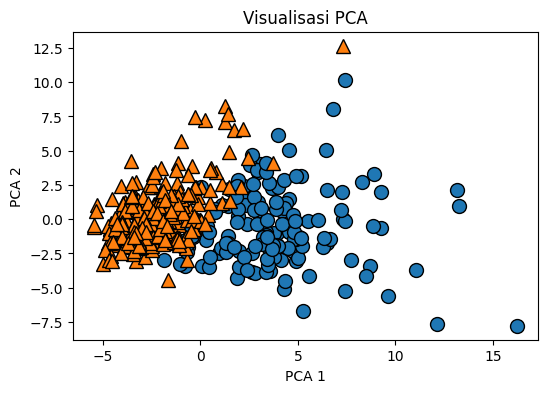

Cluster KMeans: [0 1 0 1 1 0 0 0 0 0]
Cluster DBSCAN: [ 0 -1 -1 -1 -1 -1  0  0 -1 -1]


In [6]:
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans, DBSCAN
import mglearn

# scaling data
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# reduksi dimensi pakai PCA
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_train_scaled)

# plot grafik PCA
plt.figure(figsize=(6, 4))
mglearn.discrete_scatter(X_pca[:, 0], X_pca[:, 1], y_train)
plt.xlabel("PCA 1")
plt.ylabel("PCA 2")
plt.title("Visualisasi PCA")
plt.show()

# Clustering
kmeans = KMeans(n_clusters=2, random_state=0)
pred_kmeans = kmeans.fit_predict(X_train_scaled)

db = DBSCAN(eps=2.0, min_samples=5)
pred_db = db.fit_predict(X_train_scaled)

print("Cluster KMeans:", pred_kmeans[:10])
print("Cluster DBSCAN:", pred_db[:10])